# Physics-Informed Neural Networks (PINNs)

Physics-informed neural networks (PINNs) integrate physical laws, typically expressed as differential equations, directly into the neural network's training process. By penalizing the model when it violates these laws, PINNs generate highly accurate, physically consistent predictions—even when working with very sparse real-world data.

PINNs are a class of physics-informed machine learning methods that seamlessly integrate physics knowledge with data. Often, PINNs get compared with purely data-driven methods and traditional numerical methods for solving problems involving PDEs and ODEs. 

Unlike purely data-driven approaches, which learn mathematical relationships solely from input and output data, PINNs:

* Use prior physics knowledge.
* Make more accurate predictions outside of the training data set.
* Are more effective with limited or noisy training data.

PINNs differ from traditional neural networks in their ability to incorporate a priori domain knowledge of the problem in the form of differential equations. This additional information enables PINNs to make more accurate predictions outside of the given measurement data. Furthermore, the additional physics knowledge regularizes the predicted solution in the presence of noisy measurement data, enabling PINNs to learn the true underlying signal rather than overfitting the noisy data. 

---

## Example: Solving a 1D Heat Equation with a PINN

To demonstrate how PINNs work, we'll solve a simple boundary value problem governed by the one-dimensional steady-state heat equation:

$$
\frac{\partial u}{\partial t}
=
\alpha
\frac{\partial^2 u}{\partial x^2}
$$

where:

- $u(x)$ represents the temperature distribution along a rod.
- $x$ is the position along the rod.
- The rod extends from $x=0$ to $x=1$.

### Boundary Conditions

Assume the rod has fixed temperatures at both ends:

$$
u(0)=0,
u(1)=1
$$
The analytical solution is simply:



Our goal is to train a neural network to discover this solution without directly providing the function itself.

### PINN Architecture

The neural network takes a spatial coordinate $x$ as input and predicts the temperature $u(x)$:

Epoch     0 | Total: 2.290984e-01 | Physics: 6.401317e-02 | Boundary: 1.650853e-01
Epoch   500 | Total: 8.859196e-05 | Physics: 8.821227e-05 | Boundary: 3.796862e-07
Epoch  1000 | Total: 6.192709e-06 | Physics: 6.188367e-06 | Boundary: 4.341407e-09
Epoch  1500 | Total: 4.307875e-06 | Physics: 4.306803e-06 | Boundary: 1.071782e-09
Epoch  2000 | Total: 3.014701e-06 | Physics: 3.014098e-06 | Boundary: 6.022322e-10
Epoch  2500 | Total: 2.040892e-06 | Physics: 2.039252e-06 | Boundary: 1.640030e-09
Epoch  3000 | Total: 1.415880e-06 | Physics: 1.405995e-06 | Boundary: 9.884969e-09
Epoch  3500 | Total: 9.841243e-07 | Physics: 9.783513e-07 | Boundary: 5.772972e-09
Epoch  4000 | Total: 6.821205e-07 | Physics: 6.819613e-07 | Boundary: 1.591685e-10
Epoch  4500 | Total: 4.797505e-07 | Physics: 4.796837e-07 | Boundary: 6.678660e-11


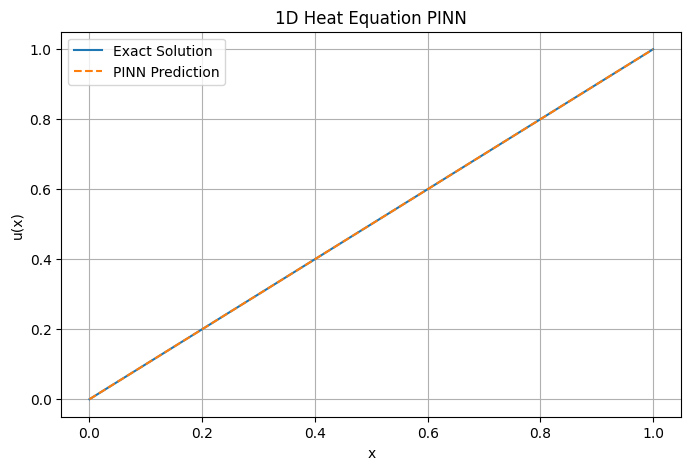

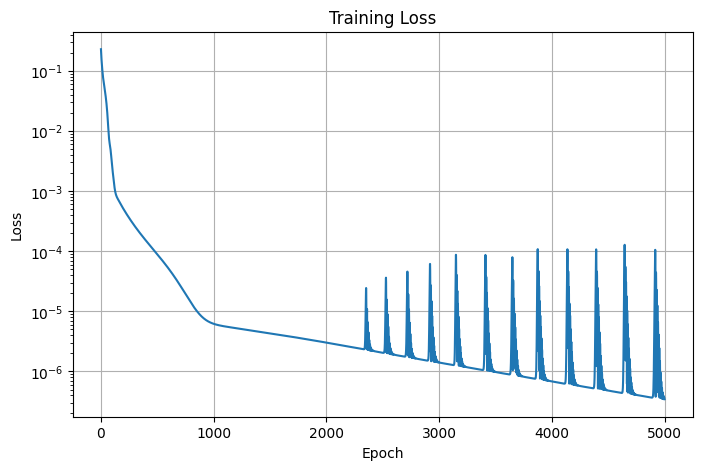

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Domain points
N_f = 1000  # collocation points

x_f = np.random.rand(N_f, 1)
x_f = tf.convert_to_tensor(x_f, dtype=tf.float32)

# Boundary conditions
x_bc = tf.constant([[0.0],
                    [1.0]], dtype=tf.float32)

u_bc = tf.constant([[0.0],
                    [1.0]], dtype=tf.float32)


# Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(1)
])

# PDE Residual
def pde_residual(x):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)

        with tf.GradientTape() as tape1:
            tape1.watch(x)
            u = model(x)

        u_x = tape1.gradient(u, x)

    u_xx = tape2.gradient(u_x, x)

    del tape2

    return u_xx

# Loss Function
def loss_function():

    # Physics loss
    f = pde_residual(x_f)
    physics_loss = tf.reduce_mean(tf.square(f))

    # Boundary loss
    u_pred_bc = model(x_bc)
    boundary_loss = tf.reduce_mean(
        tf.square(u_pred_bc - u_bc)
    )

    total_loss = physics_loss + boundary_loss

    return total_loss, physics_loss, boundary_loss

# Training
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

epochs = 5000

loss_history = []

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        total_loss, physics_loss, boundary_loss = loss_function()

    grads = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    loss_history.append(total_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_loss.numpy():.6e} | "
            f"Physics: {physics_loss.numpy():.6e} | "
            f"Boundary: {boundary_loss.numpy():.6e}"
        )

# Prediction
x_test = np.linspace(0, 1, 200).reshape(-1, 1)

u_pred = model(
    tf.convert_to_tensor(
        x_test,
        dtype=tf.float32
    )
).numpy()

# Analytical solution
u_exact = x_test

# Plot Solution
plt.figure(figsize=(8,5))

plt.plot(
    x_test,
    u_exact,
    label="Exact Solution"
)

plt.plot(
    x_test,
    u_pred,
    "--",
    label="PINN Prediction"
)

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("1D Heat Equation PINN")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))

plt.semilogy(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.show()

In [1]:
# YOUR TURN! Implement a PINN to solve the simple harmonic oscillator numerically.

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Physical parameters
m = 1.0      # mass
c = 4.0      # damping coefficient  
k = 400.0    # spring constant

# Derived parameters
delta = c / (2 * m)                # damping ratio
omega_0 = np.sqrt(k / m)           # natural frequency
omega = np.sqrt(omega_0**2 - delta**2) # damped frequency

print(f"Physical parameters:")
print(f"  δ = {delta:.2f} (damping ratio)")
print(f"  ω₀ = {omega_0:.2f} (natural frequency)")
print(f"  ω = {omega:.2f} (damped frequency)")
print(f"  Underdamped: {delta < omega_0}")

Physical parameters:
  δ = 2.00 (damping ratio)
  ω₀ = 20.00 (natural frequency)
  ω = 19.90 (damped frequency)
  Underdamped: True


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def oscillator(d, w0, x):
    """Analytical solution to the 1D underdamped harmonic oscillator problem."""
    assert d < w0
    w = np.sqrt(w0**2 - d**2)
    phi = np.arctan(-d / w)
    A = 1 / (2 * np.cos(phi))
    cos = np.cos(phi + w * x)
    exp = np.exp(-d * x)
    y = exp * 2 * A * cos
    return y

def create_spring_oscillator_animation_inline():
    d = 2  # damping coefficient
    w0 = 20  # natural frequency
    
    # Animation variables
    totalTime = 1.0  # Time domain [0, 1]
    dt = 0.0075
    t_array = np.arange(0, totalTime, dt)
    y_array = oscillator(d, w0, t_array)

    # Scaling factors
    scale = 1.0
    centerY = 0.0

    # Compute y_min and y_max from the displacement data
    y_min = np.min(y_array * scale + centerY)
    y_max = np.max(y_array * scale + centerY)

    # Create figure and axes
    fig, (ax_trace, ax_spring) = plt.subplots(1, 2, figsize=(12, 4))
    plt.tight_layout(pad=3.0)

    # Plot the displacement curve on ax_trace
    ax_trace.plot(t_array, y_array * scale + centerY, color='gray')
    trace_point, = ax_trace.plot([], [], 'bo', markersize=8)
    ax_trace.set_xlim(0, totalTime)
    ax_trace.set_ylim(-1.1, 1.1)  
    ax_trace.set_xlabel('Time (s)')
    ax_trace.set_ylabel('Displacement')
    ax_trace.set_title('Displacement vs. Time')

    # Set up the mass-spring system on ax_spring
    ax_spring.set_xlim(-1, 1)
    ax_spring.set_ylim(-1.1, 1.1)  
    ax_spring.axis('off')
    ax_spring.set_title('Mass-Spring System')

    # Draw the fixed block at equilibrium position (y=0)
    ax_spring.plot([-0.2, 0.2], [1.0, 1.0], 'k-', linewidth=4)

    # Initialize the mass and spring
    mass, = ax_spring.plot([], [], 'bo', markersize=20)
    spring_line, = ax_spring.plot([], [], 'k-', linewidth=1.5)

    def get_spring(y_start, y_end, coils=10, points_per_coil=15):
        length = y_end - y_start
        t = np.linspace(0, 1, coils * points_per_coil)
        x = 0.06 * np.sin(2 * np.pi * coils * t)
        y = y_start + length * t
        return x, y

    def update(frame):
        t = t_array[frame % len(t_array)]
        y = oscillator(d, w0, t) * scale + centerY

        # Update trace point
        trace_point.set_data([t], [y])

        # Update mass position
        mass.set_data([0], [y])

        # Update spring
        x_spring, y_spring = get_spring(1.0, y)  # Starting from y=1.0 (fixed point)
        spring_line.set_data(x_spring, y_spring)

        return trace_point, mass, spring_line

    ani = FuncAnimation(fig, update, frames=len(t_array), interval=20, blit=True)

    plt.close(fig)

# Call the function to display the animation
create_spring_oscillator_animation_inline()

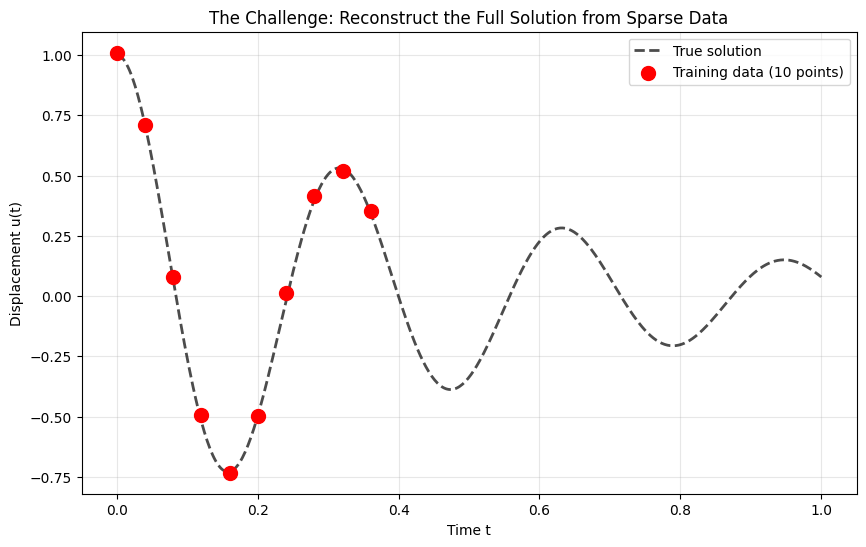

Training data: 10 points with noise level 0.02
Challenge: Can a neural network reconstruct the full solution?


In [3]:
# Generate sparse training data
n_data = 10  # Only 10 data points!

def exact_solution(t):
    """Analytical solution to the damped harmonic oscillator"""
    return np.exp(-delta * t) * (np.cos(omega * t) + (delta/omega) * np.sin(omega * t))

# Get solution
t_data = np.linspace(0, 0.3607, n_data)
u_data = exact_solution(t_data)

# Exact solution
t_exact = np.linspace(0, 1, 500)
u_exact = exact_solution(t_exact)


# Add some noise to make it realistic
noise_level = 0.02
u_data_noisy = u_data + noise_level * np.random.normal(0, 1, len(u_data))

# Visualize the sparse data
plt.figure(figsize=(10, 6))
plt.plot(t_exact, u_exact, 'k--', linewidth=2, alpha=0.7, label='True solution')
plt.scatter(t_data, u_data_noisy, color='red', s=100, zorder=5, label=f'Training data ({n_data} points)')
plt.xlabel('Time t')
plt.ylabel('Displacement u(t)')
plt.title('The Challenge: Reconstruct the Full Solution from Sparse Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training data: {n_data} points with noise level {noise_level}")
print("Challenge: Can a neural network reconstruct the full solution?")

In [ ]:
def compute_derivatives_demo():
    """Demonstrate automatic differentiation"""
    # Create a simple test case: u(t) = sin(t)
    t = torch.tensor([0.5], requires_grad=True)  # Enable gradient computation
    u = torch.sin(t)  # u = sin(t)
    
    print("Function: u(t) = sin(t)")
    print(f"At t = {t.item():.2f}:")
    print(f"  u = {u.item():.6f}")
    
    # First derivative: du/dt
    du_dt = torch.autograd.grad(u, t, create_graph=True)[0]
    print(f"  du/dt = {du_dt.item():.6f} (exact: cos({t.item():.2f}) = {np.cos(t.item()):.6f})")
    
    # Second derivative: d²u/dt²
    d2u_dt2 = torch.autograd.grad(du_dt, t, create_graph=True)[0]
    print(f"  d²u/dt² = {d2u_dt2.item():.6f} (exact: -sin({t.item():.2f}) = {-np.sin(t.item()):.6f})")
    
    print("✅ Automatic differentiation gives exact derivatives!")

compute_derivatives_demo()

Function: u(t) = sin(t)
At t = 0.50:
  u = 0.479426
  du/dt = 0.877583 (exact: cos(0.50) = 0.877583)
  d²u/dt² = -0.479426 (exact: -sin(0.50) = -0.479426)
✅ Automatic differentiation gives exact derivatives!


In [12]:
%pip install tqdm
from tqdm import tqdm

class SimpleNN(nn.Module):
    """Standard feedforward neural network"""
    def __init__(self, hidden_size=32, n_layers=3):
        super().__init__()
        
        layers = []
        layers.append(nn.Linear(1, hidden_size))  # Input: time t
        
        # Hidden layers
        for _ in range(n_layers):
            layers.append(nn.Tanh())  # Smooth activation (important!)
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_size, 1))  # Output: displacement u
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, t):
        return self.network(t)

# Convert data to PyTorch tensors
t_data_tensor = torch.tensor(t_data.reshape(-1, 1), dtype=torch.float32)
u_data_tensor = torch.tensor(u_data_noisy.reshape(-1, 1), dtype=torch.float32)
t_test_tensor = torch.tensor(t_exact.reshape(-1, 1), dtype=torch.float32)

print("Data shapes:")
print(f"  Training: {t_data_tensor.shape} -> {u_data_tensor.shape}")
print(f"  Testing: {t_test_tensor.shape}")

def train_standard_nn(model, t_data, u_data, epochs=5000, lr=1e-3):
    """Train a standard neural network on data only"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    
    # Training loop
    pbar = tqdm(range(epochs), desc="Training Standard NN")
    for epoch in pbar:
        optimizer.zero_grad()
        # Forward pass
        u_pred = model(t_data)
        # Data loss only
        loss = criterion(u_pred, u_data)
        # Backward pass
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        # Update progress bar with loss information every 100 epochs
        if (epoch + 1) % 100 == 0:
            pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
        
    return losses

# Create and train the standard neural network
standard_nn = SimpleNN()
losses_standard = train_standard_nn(standard_nn, t_data_tensor, u_data_tensor)
print(f"Final training loss: {losses_standard[-1]:.2e}")

# Test the physics loss function
test_model = SimpleNN()
t_test_colloc = torch.linspace(0, 1, 50).reshape(-1, 1)
test_loss = physics_loss(test_model, t_test_colloc, m, c, k)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Data shapes:
  Training: torch.Size([10, 1]) -> torch.Size([10, 1])
  Testing: torch.Size([500, 1])


Training Standard NN: 100%|██████████| 5000/5000 [00:24<00:00, 205.31it/s, Loss=0.000002]


Final training loss: 2.26e-06


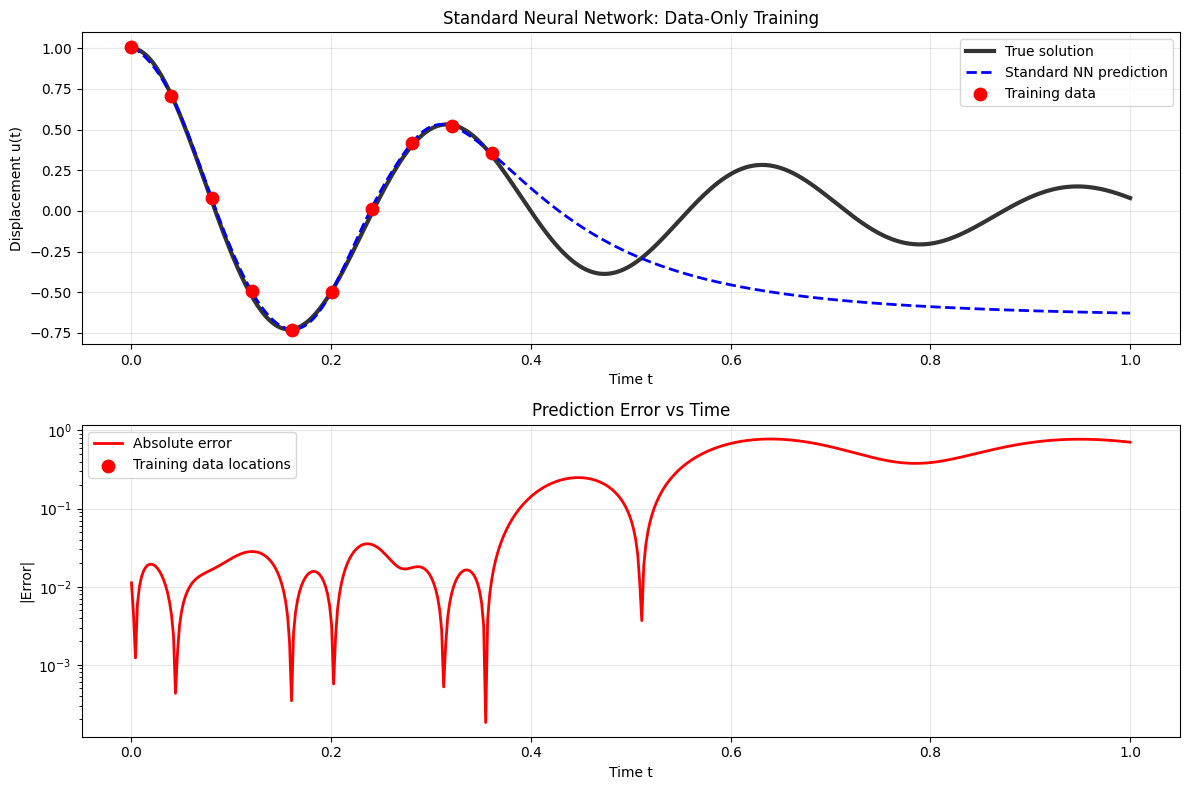

 Standard NN Performance:
  MSE: 0.179839
  Max Error: 0.777235


In [10]:
# Make predictions on the full time domain
with torch.no_grad():
    u_pred_standard = standard_nn(t_test_tensor).numpy().flatten()

# Visualize the results
plt.figure(figsize=(12, 8))

# Plot 1: Full comparison
plt.subplot(2, 1, 1)
plt.plot(t_exact, u_exact, 'k-', linewidth=3, label='True solution', alpha=0.8)
plt.plot(t_exact, u_pred_standard, 'b--', linewidth=2, label='Standard NN prediction')
plt.scatter(t_data, u_data_noisy, color='red', s=80, zorder=5, label='Training data')
plt.xlabel('Time t')
plt.ylabel('Displacement u(t)')
plt.title('Standard Neural Network: Data-Only Training')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error analysis
plt.subplot(2, 1, 2)
error = np.abs(u_pred_standard - u_exact)
plt.plot(t_exact, error, 'r-', linewidth=2, label='Absolute error')
plt.scatter(t_data, np.zeros_like(t_data), color='red', s=80, zorder=5, 
            label='Training data locations')
plt.xlabel('Time t')
plt.ylabel('|Error|')
plt.title('Prediction Error vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

# Compute metrics
mse = np.mean((u_pred_standard - u_exact)**2)
max_error = np.max(np.abs(u_pred_standard - u_exact))

print(f" Standard NN Performance:")
print(f"  MSE: {mse:.6f}")
print(f"  Max Error: {max_error:.6f}")

In [11]:
def physics_loss(model, t_colloc, m, c, k):
    """
    Compute the physics loss for the damped harmonic oscillator
    
    ODE: m * d²u/dt² + c * du/dt + k * u = 0
    """
    # Ensure gradients are enabled for input
    t_colloc = t_colloc.clone().detach().requires_grad_(True)
    
    # Forward pass: compute u(t)
    u = model(t_colloc)
    
    # First derivative: du/dt
    du_dt = torch.autograd.grad(
        outputs=u, 
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u),
        create_graph=True,  # Allow higher-order derivatives
        retain_graph=True
    )[0]
    
    # Second derivative: d²u/dt²
    d2u_dt2 = torch.autograd.grad(
        outputs=du_dt,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(du_dt),
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Physics residual: R = m * d²u/dt² + c * du/dt + k * u
    residual = m * d2u_dt2 + c * du_dt + k * u
    
    # Mean squared residual
    physics_loss = torch.mean(residual**2)
    
    return physics_loss

print(f"Physics loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Physics loss (untrained model): 1145.583496
This is large since the model hasn't learned the physics yet!


Collocation points: uniformly distributed in [0, 1]
Physics weight λ = 0.0001 (typically much smaller than 1)


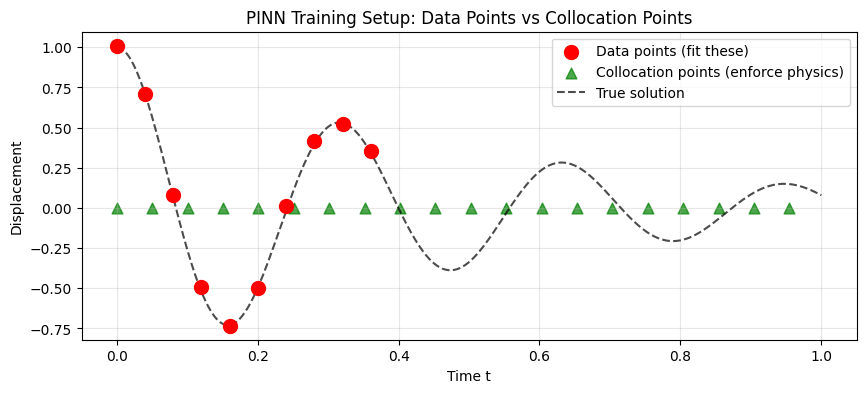

In [13]:
def train_pinn(model, t_data, u_data, t_colloc, m, c, k, 
               epochs=10000, lr=1e-3, lambda_physics=1e-4):
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        t_data, u_data: Training data points
        t_colloc: Collocation points for physics
        m, c, k: Physical parameters
        lambda_physics: Balance parameter between data and physics
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Storage for loss history
    data_losses = []
    physics_losses = []
    total_losses = []
    
    print(f"Training PINN with λ = {lambda_physics}")
    print(f"Data points: {len(t_data)}, Collocation points: {len(t_colloc)}")

    pbar = tqdm(range(epochs), desc="Training PINN")
    for epoch in pbar:
        optimizer.zero_grad()
        
        # Data loss: how well do we fit the measurements?
        u_pred_data = model(t_data)
        loss_data = criterion(u_pred_data, u_data)
        
        # Physics loss: how well do we satisfy the ODE?
        loss_physics = physics_loss(model, t_colloc, m, c, k)
        
        # Total loss: balance data fitting and physics
        total_loss = loss_data + lambda_physics * loss_physics
        
        # Backpropagation
        total_loss.backward()
        optimizer.step()
        
        # Store losses
        data_losses.append(loss_data.item())
        physics_losses.append(loss_physics.item())
        total_losses.append(total_loss.item())
        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Loss': f'{loss_data.item():.6f}', 
                              'Physics': f'{loss_physics.item():.6f}', 
                              'Total': f'{total_loss.item():.6f}'})
        
    return data_losses, physics_losses, total_losses

# Setup for PINN training
n_colloc = 200  # Number of collocation points
t_colloc = torch.linspace(0, 1, n_colloc).reshape(-1, 1)
lambda_physics = 1e-4  # Balance parameter

print(f"Collocation points: uniformly distributed in [0, 1]")
print(f"Physics weight λ = {lambda_physics} (typically much smaller than 1)")

# Visualize training setup
plt.figure(figsize=(10, 4))
plt.scatter(t_data, u_data_noisy, color='red', s=100, zorder=5, label='Data points (fit these)')
plt.scatter(t_colloc.numpy().flatten()[::10], np.zeros(len(t_colloc[::10])), 
            color='green', marker='^', s=60, alpha=0.7, label='Collocation points (enforce physics)')
plt.plot(t_exact, u_exact, 'k--', alpha=0.7, label='True solution')
plt.xlabel('Time t')
plt.ylabel('Displacement')
plt.title('PINN Training Setup: Data Points vs Collocation Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Create a fresh PINN model
pinn_model = SimpleNN()

# Train the PINN
data_losses, physics_losses, total_losses = train_pinn(
    pinn_model, t_data_tensor, u_data_tensor, t_colloc, m, c, k, epochs=20000
)

# Make predictions
with torch.no_grad():
    u_pred_pinn = pinn_model(t_test_tensor).numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final data loss: {data_losses[-1]:.6f}")
print(f"Final physics loss: {physics_losses[-1]:.6f}")

Training PINN with λ = 0.0001
Data points: 10, Collocation points: 200


Training PINN: 100%|██████████| 20000/20000 [05:27<00:00, 61.10it/s, Loss=0.000201, Physics=1.544963, Total=0.000355] 

PINN Training Complete!
Final data loss: 0.000201
Final physics loss: 1.544963


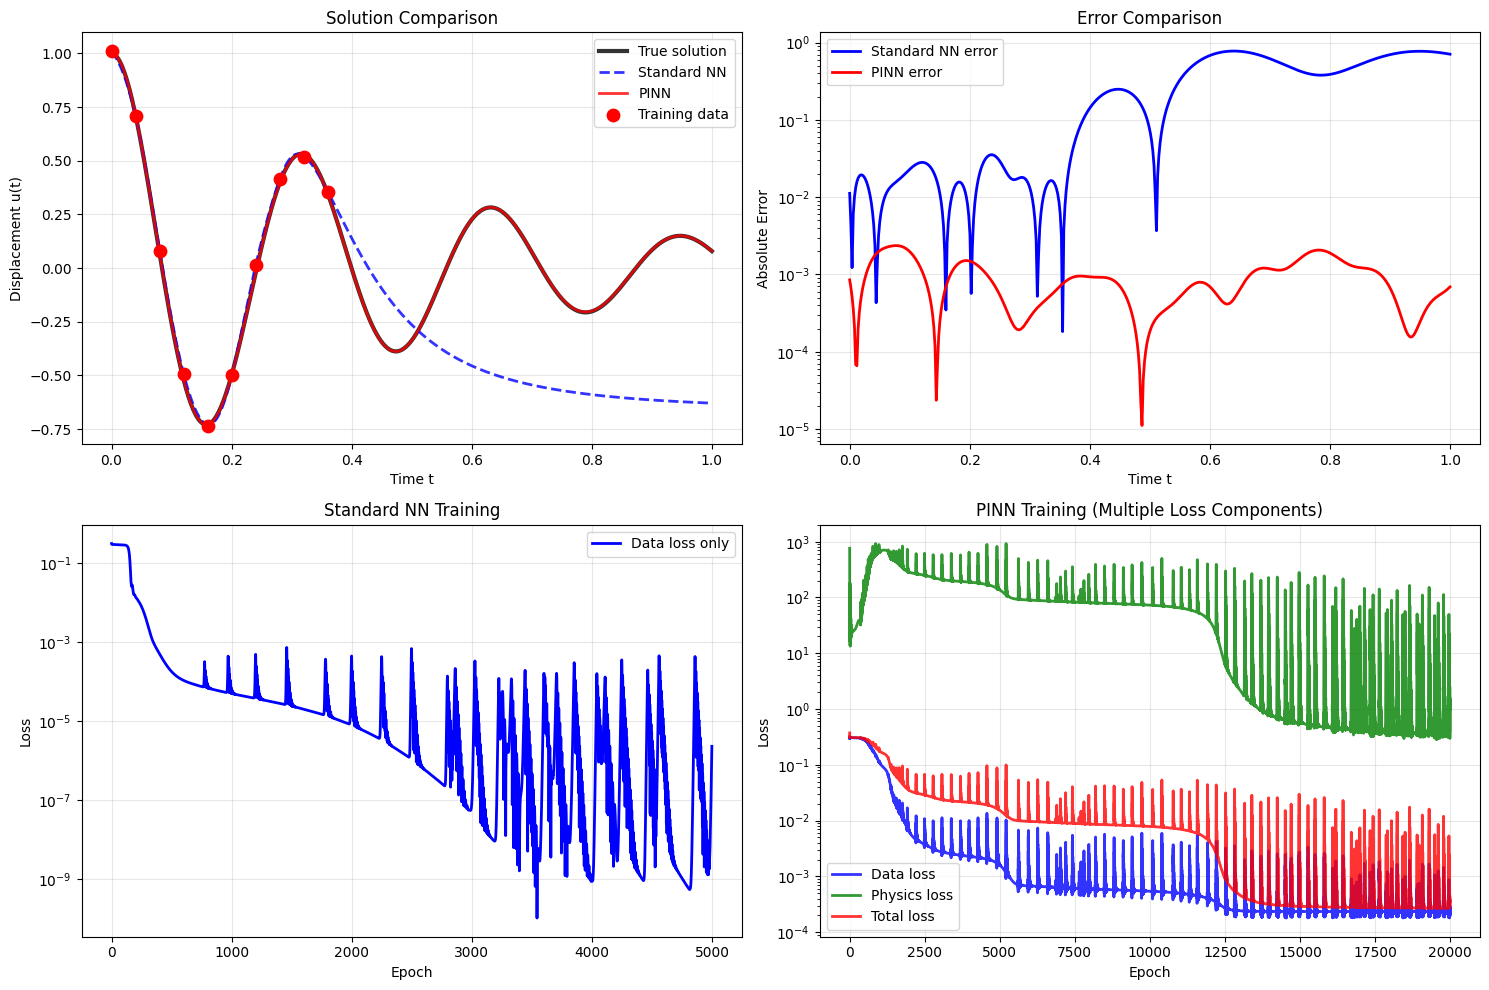

📊 QUANTITATIVE COMPARISON
Metric               Standard NN     PINN            Improvement    
-----------------------------------------------------------------
MSE                  0.179839        0.000001        153949.7       x
Max Error            0.777235        0.002365        328.7          x
✅ PINN is 153950x more accurate!


In [15]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Solutions comparison
ax = axes[0, 0]
ax.plot(t_exact, u_exact, 'k-', linewidth=3, label='True solution', alpha=0.8)
ax.plot(t_exact, u_pred_standard, 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax.plot(t_exact, u_pred_pinn, 'r-', linewidth=2, label='PINN', alpha=0.8)
ax.scatter(t_data, u_data_noisy, color='red', s=80, zorder=5, label='Training data')
ax.set_xlabel('Time t')
ax.set_ylabel('Displacement u(t)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[0, 1]
error_standard = np.abs(u_pred_standard - u_exact)
error_pinn = np.abs(u_pred_pinn - u_exact)
ax.plot(t_exact, error_standard, 'b-', linewidth=2, label='Standard NN error')
ax.plot(t_exact, error_pinn, 'r-', linewidth=2, label='PINN error')
ax.set_xlabel('Time t')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Loss evolution for Standard NN
ax = axes[1, 0]
ax.plot(losses_standard, 'b-', linewidth=2, label='Data loss only')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Standard NN Training')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Loss evolution for PINN
ax = axes[1, 1]
ax.plot(data_losses, 'b-', linewidth=2, label='Data loss', alpha=0.8)
ax.plot(physics_losses, 'g-', linewidth=2, label='Physics loss', alpha=0.8)
ax.plot(total_losses, 'r-', linewidth=2, label='Total loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('PINN Training (Multiple Loss Components)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
mse_standard = np.mean((u_pred_standard - u_exact)**2)
mse_pinn = np.mean((u_pred_pinn - u_exact)**2)
max_error_standard = np.max(np.abs(u_pred_standard - u_exact))
max_error_pinn = np.max(np.abs(u_pred_pinn - u_exact))

print("📊 QUANTITATIVE COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'Standard NN':<15} {'PINN':<15} {'Improvement':<15}")
print("-"*65)
print(f"{'MSE':<20} {mse_standard:<15.6f} {mse_pinn:<15.6f} {mse_standard/mse_pinn:<15.1f}x")
print(f"{'Max Error':<20} {max_error_standard:<15.6f} {max_error_pinn:<15.6f} {max_error_standard/max_error_pinn:<15.1f}x")

print(f"✅ PINN is {mse_standard/mse_pinn:.0f}x more accurate!")

In [16]:
def exact_velocity(t):
    """
    First derivative of the exact solution: du/dt
    
    Given: u(t) = e^(-δt) * [cos(ωt) + (δ/ω)sin(ωt)]
    
    Using product rule: d/dt[f(t)g(t)] = f'(t)g(t) + f(t)g'(t)
    where f(t) = e^(-δt) and g(t) = cos(ωt) + (δ/ω)sin(ωt)
    """
    exp_term = np.exp(-delta * t)
    cos_term = np.cos(omega * t)
    sin_term = np.sin(omega * t)
    
    # Derivative of exponential term: d/dt[e^(-δt)] = -δe^(-δt)
    d_exp_term = -delta * exp_term
    
    # Derivative of trigonometric term: d/dt[cos(ωt) + (δ/ω)sin(ωt)]
    d_trig_term = -omega * sin_term + (delta/omega) * omega * cos_term
    d_trig_term = -omega * sin_term + delta * cos_term
    
    # Apply product rule
    velocity = d_exp_term * (cos_term + (delta/omega) * sin_term) + exp_term * d_trig_term
    
    return velocity

def exact_acceleration(t):
    """
    Second derivative of the exact solution: d²u/dt²
    
    This can be computed by differentiating the velocity function,
    or directly from the ODE: d²u/dt² = -(c/m)(du/dt) - (k/m)u
    
    Using the ODE relation is more numerically stable:
    m * d²u/dt² + c * du/dt + k * u = 0
    Therefore: d²u/dt² = -(c/m) * du/dt - (k/m) * u
    """
    u = exact_solution(t)
    du_dt = exact_velocity(t)
    
    # From the ODE: m * d²u/dt² = -c * du/dt - k * u
    d2u_dt2 = -(c/m) * du_dt - (k/m) * u
    
    return d2u_dt2

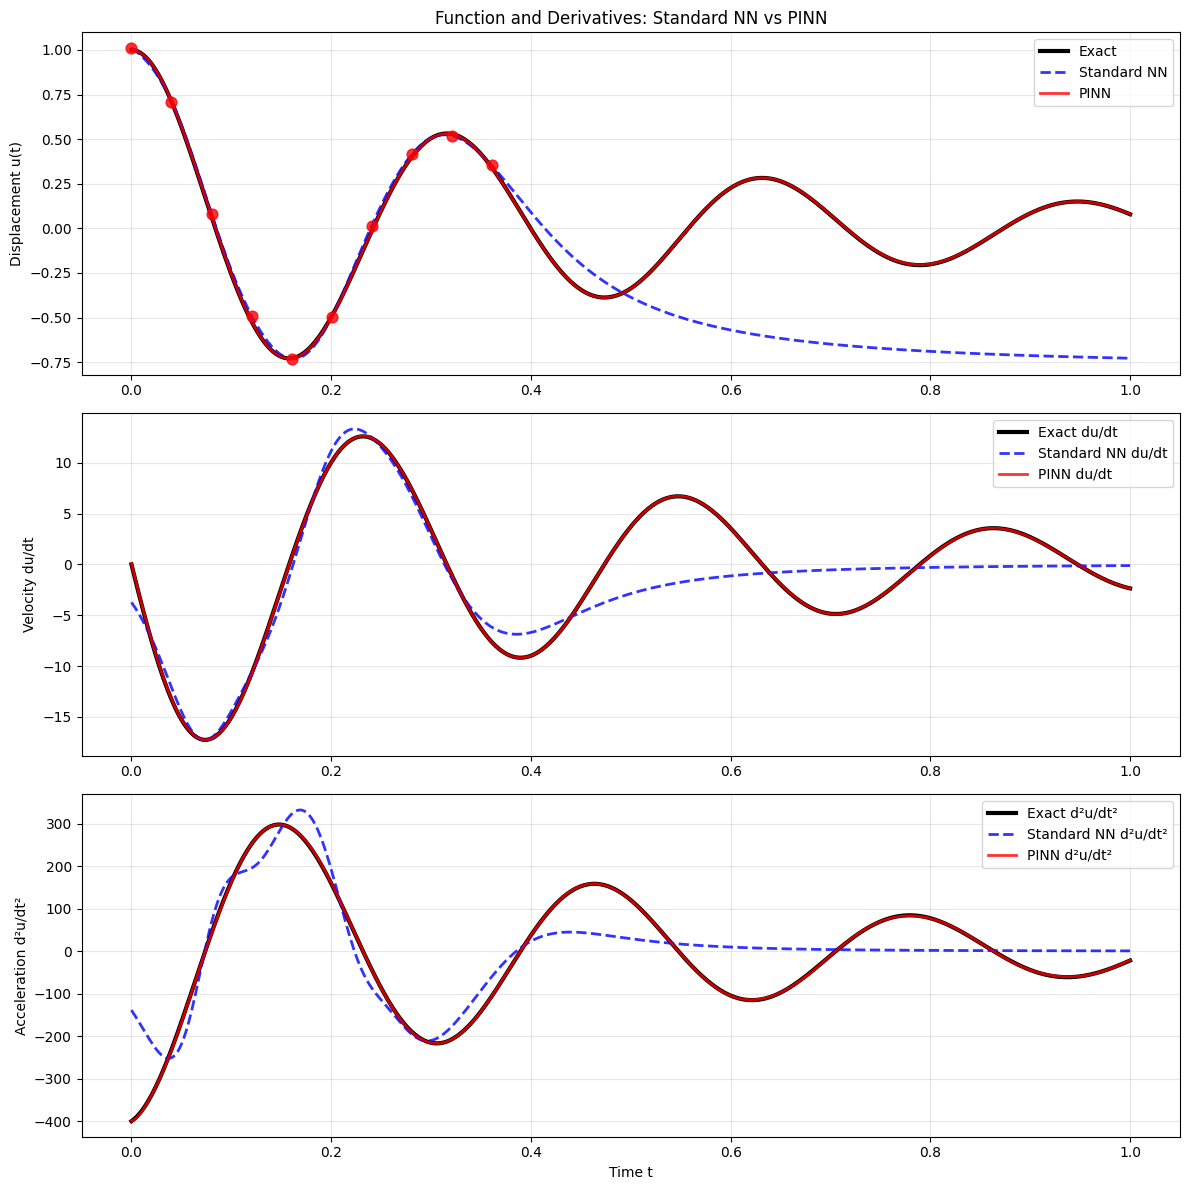

📈 DERIVATIVE ACCURACY
Velocity MSE (du/dt):
  Standard NN: 10.057185
  PINN: 0.000467
  Improvement: 21547.7x
Acceleration MSE (d²u/dt²):
  Standard NN: 4536.068186
  PINN: 0.475857
  Improvement: 9532.4x


In [17]:
def compute_model_derivatives(model, t_tensor):
    """Compute derivatives of the model using automatic differentiation"""
    t_tensor = t_tensor.clone().detach().requires_grad_(True)
    
    # Function value
    u = model(t_tensor)
    
    # First derivative
    du_dt = torch.autograd.grad(u, t_tensor, grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)[0]
    
    # Second derivative
    d2u_dt2 = torch.autograd.grad(du_dt, t_tensor, grad_outputs=torch.ones_like(du_dt),
                                 create_graph=True, retain_graph=True)[0]
    
    return u.detach().numpy(), du_dt.detach().numpy(), d2u_dt2.detach().numpy()

# Compute derivatives for both models
# REMOVED torch.no_grad() context - this was causing the error
# Standard NN derivatives
u_std, du_dt_std, d2u_dt2_std = compute_model_derivatives(standard_nn, t_test_tensor)

# PINN derivatives
u_pinn, du_dt_pinn, d2u_dt2_pinn = compute_model_derivatives(pinn_model, t_test_tensor)

# Analytical derivatives for comparison
v_exact = exact_velocity(t_exact)
a_exact = exact_acceleration(t_exact)

# Plot derivative comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Displacement
ax = axes[0]
ax.plot(t_exact, u_exact, 'k-', linewidth=3, label='Exact')
ax.plot(t_exact, u_std.flatten(), 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax.plot(t_exact, u_pinn.flatten(), 'r-', linewidth=2, label='PINN', alpha=0.8)
ax.scatter(t_data, u_data_noisy, color='red', s=60, zorder=5, alpha=0.8)
ax.set_ylabel('Displacement u(t)')
ax.set_title('Function and Derivatives: Standard NN vs PINN')
ax.legend()
ax.grid(True, alpha=0.3)

# First derivative (velocity)
ax = axes[1]
ax.plot(t_exact, v_exact, 'k-', linewidth=3, label='Exact du/dt')
ax.plot(t_exact, du_dt_std.flatten(), 'b--', linewidth=2, label='Standard NN du/dt', alpha=0.8)
ax.plot(t_exact, du_dt_pinn.flatten(), 'r-', linewidth=2, label='PINN du/dt', alpha=0.8)
ax.set_ylabel('Velocity du/dt')
ax.legend()
ax.grid(True, alpha=0.3)

# Second derivative (acceleration)
ax = axes[2]
ax.plot(t_exact, a_exact, 'k-', linewidth=3, label='Exact d²u/dt²')
ax.plot(t_exact, d2u_dt2_std.flatten(), 'b--', linewidth=2, label='Standard NN d²u/dt²', alpha=0.8)
ax.plot(t_exact, d2u_dt2_pinn.flatten(), 'r-', linewidth=2, label='PINN d²u/dt²', alpha=0.8)
ax.set_ylabel('Acceleration d²u/dt²')
ax.set_xlabel('Time t')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Derivative errors
print("📈 DERIVATIVE ACCURACY")
print("="*40)

velocity_error_std = np.mean((du_dt_std.flatten() - v_exact)**2)
velocity_error_pinn = np.mean((du_dt_pinn.flatten() - v_exact)**2)
accel_error_std = np.mean((d2u_dt2_std.flatten() - a_exact)**2)
accel_error_pinn = np.mean((d2u_dt2_pinn.flatten() - a_exact)**2)

print(f"Velocity MSE (du/dt):")
print(f"  Standard NN: {velocity_error_std:.6f}")
print(f"  PINN: {velocity_error_pinn:.6f}")
print(f"  Improvement: {velocity_error_std/velocity_error_pinn:.1f}x")

print(f"Acceleration MSE (d²u/dt²):")
print(f"  Standard NN: {accel_error_std:.6f}")
print(f"  PINN: {accel_error_pinn:.6f}")
print(f"  Improvement: {accel_error_std/accel_error_pinn:.1f}x")

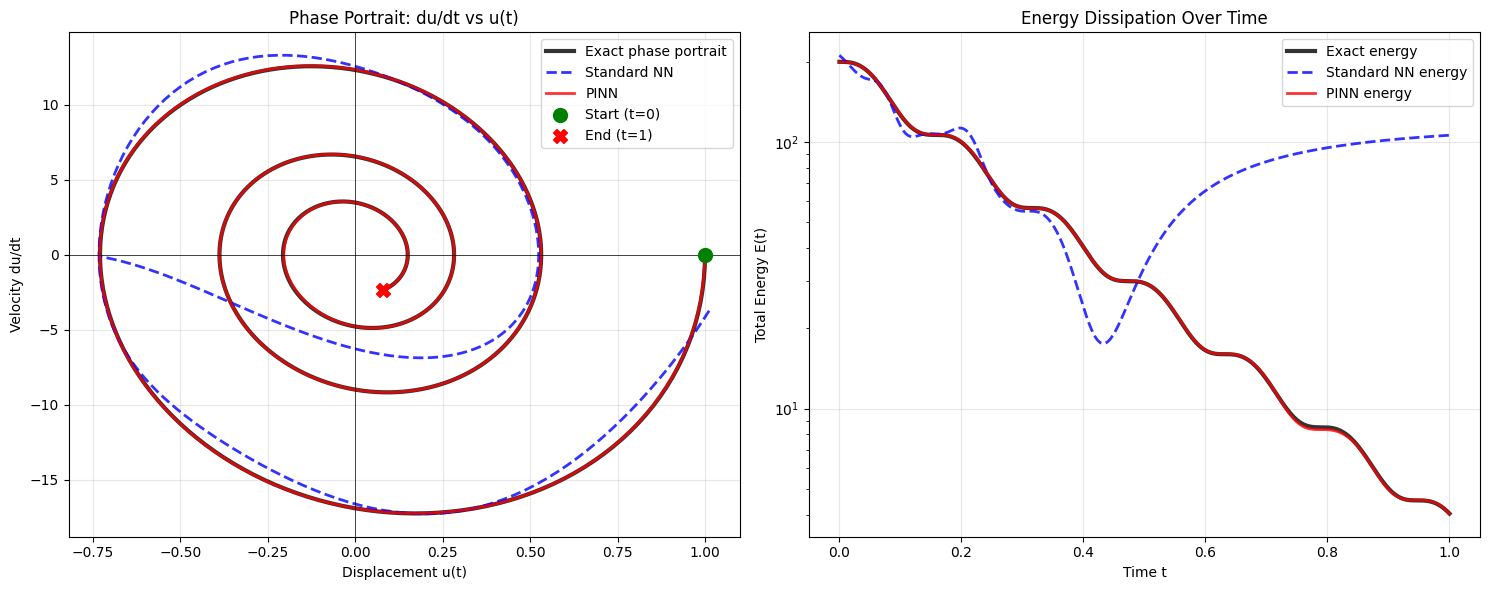

In [18]:
# Analytical derivatives for comparison
t_exact = np.linspace(0, 1, 500)
v_exact = exact_velocity(t_exact)
a_exact = exact_acceleration(t_exact)

# Phase Portrait Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Phase Portrait
ax1.plot(u_exact, v_exact, 'k-', linewidth=3, label='Exact phase portrait', alpha=0.8)
ax1.plot(u_std.flatten(), du_dt_std.flatten(), 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax1.plot(u_pinn.flatten(), du_dt_pinn.flatten(), 'r-', linewidth=2, label='PINN', alpha=0.8)

# Mark start and end points
ax1.scatter(u_exact[0], v_exact[0], color='green', s=100, marker='o', zorder=5, label='Start (t=0)')
ax1.scatter(u_exact[-1], v_exact[-1], color='red', s=100, marker='X', zorder=5, label='End (t=1)')

ax1.set_xlabel('Displacement u(t)')
ax1.set_ylabel('Velocity du/dt')
ax1.set_title('Phase Portrait: du/dt vs u(t)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)

# Plot 2: Energy Analysis
# Total energy E = (1/2)m*v² + (1/2)k*u² for undamped case
# For damped oscillator, energy should decrease monotonically
energy_exact = 0.5 * m * v_exact**2 + 0.5 * k * u_exact**2
energy_std = 0.5 * m * du_dt_std.flatten()**2 + 0.5 * k * u_std.flatten()**2
energy_pinn = 0.5 * m * du_dt_pinn.flatten()**2 + 0.5 * k * u_pinn.flatten()**2

ax2.plot(t_exact, energy_exact, 'k-', linewidth=3, label='Exact energy', alpha=0.8)
ax2.plot(t_exact, energy_std, 'b--', linewidth=2, label='Standard NN energy', alpha=0.8)
ax2.plot(t_exact, energy_pinn, 'r-', linewidth=2, label='PINN energy', alpha=0.8)
ax2.set_xlabel('Time t')
ax2.set_ylabel('Total Energy E(t)')
ax2.set_title('Energy Dissipation Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()